# FireGuard Orbit — Predição de Risco de Queimadas

**GS — Cognitive Computing, Computer Vision and IoT Systems | FIAP**  
**Tema:** Space Connect — Prevenção de Queimadas com Machine Learning

### Base final utilizada
| Componente | Origem |
|---|---|
| **Focos de queimadas** | INPE Queimadas — focos reais agregados por data, região e bioma |
| **Variáveis meteorológicas** | NASA POWER — temperatura, umidade, precipitação e vento reais |
| **Variáveis históricas** | Calculadas a partir dos próprios focos e do clima real |

> Nesta versão, as variáveis ambientais simuladas foram substituídas por dados reais da NASA POWER.

### Integrantes
| Nome | RM |
|---|---:|
| PEDRO LOTÉRIO DOS SANTOS | 550909 |
| RAFAEL BUENO VILLELA | 550275 |
| LUCAS THOMAZETTE BENVENUTO | 98048 |

## 1. Problema e objetivo

Queimadas são um dos principais vetores de degradação ambiental no Brasil. A detecção antecipada de áreas com maior risco permite priorizar ações preventivas.

**Tipo de problema:** classificação binária supervisionada.  
**Variável alvo:** `risco_alto_queimada` — 1 = risco alto; 0 = risco normal.  
**Objetivo:** prever risco alto no próximo dia/período para cada combinação de região e bioma.

In [1]:
# ── Importações ─────────────────────────────────────────────────────────────
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")

import warnings
warnings.filterwarnings('ignore')

import json
import inspect
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'data'
GRAF_DIR = BASE_DIR / 'graficos'
GRAF_DIR.mkdir(exist_ok=True)

print('[OK] Bibliotecas carregadas')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

def make_ohe():
    """Compatível com versões antigas e novas do scikit-learn."""
    params = {'handle_unknown': 'ignore'}
    if 'sparse_output' in inspect.signature(OneHotEncoder).parameters:
        params['sparse_output'] = False
    else:
        params['sparse'] = False
    return OneHotEncoder(**params)


[OK] Bibliotecas carregadas
pandas 2.2.3 | numpy 2.3.5


## 2. Carregamento da base real

A base final está em `data/dados_fireguard_orbit_real.csv`.

Ela foi construída a partir de:

- `data/focos_inpe_agregado_2025.csv`: focos reais agregados do INPE;
- `data/nasa_power/nasa_power_biomas_2025.csv`: clima real da NASA POWER;
- variáveis históricas calculadas no script `scripts/02_montar_base_real_fireguard.py`.

In [2]:
CSV_REAL = DATA_DIR / 'dados_fireguard_orbit_real.csv'

if not CSV_REAL.exists():
    raise FileNotFoundError('Base real não encontrada. Rode scripts/02_montar_base_real_fireguard.py')

df = pd.read_csv(CSV_REAL, parse_dates=['data'])

print('[OK] Base real carregada:', CSV_REAL)
print(f'Linhas  : {df.shape[0]:,}')
print(f'Colunas : {df.shape[1]}')
print(f'Período : {df["data"].min().date()} até {df["data"].max().date()}')
print(f'Biomas  : {sorted(df["bioma"].unique())}')
print(f'Regiões : {sorted(df["regiao"].unique())}')
print(f'Total de focos observados: {df["focos_observados"].sum():,.0f}')

df.head()

[OK] Base real carregada: data/dados_fireguard_orbit_real.csv
Linhas  : 2,099
Colunas : 28
Período : 2025-01-01 até 2025-05-30
Biomas  : ['Amazônia', 'Caatinga', 'Cerrado', 'Mata Atlântica', 'Pampa', 'Pantanal']
Regiões : ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
Total de focos observados: 285,465


,data,ano,mes,regiao,bioma,focos_observados,cidade_ref,lat_ref,lon_ref,temperatura_c,temperatura_max_c,temperatura_min_c,umidade_pct,precipitacao_mm,vento_ms,vento_kmh,focos_dia_anterior,focos_acumulados_7d,media_focos_7d,media_focos_15d,chuva_acumulada_7d,umidade_media_7d,temperatura_media_7d,dias_sem_chuva,focos_proximo_dia,limiar_risco_bioma,risco_alto_queimada,dia_do_ano
0,2025-01-01,2025,1,Centro-Oeste,Amazônia,168,Manaus,-3.119,-60.0217,27.08,29.65,25.21,86.59,3.76,1.31,4.716,0.0,0.0,0.000000,0.000000,0.00,86.590,27.080000,0,7.0,152.25,0,1
1,2025-01-02,2025,1,Centro-Oeste,Amazônia,7,Manaus,-3.119,-60.0217,26.50,28.88,24.78,88.44,11.84,1.23,4.428,168.0,168.0,168.000000,168.000000,3.76,86.590,27.080000,0,36.0,152.25,0,2
2,2025-01-03,2025,1,Centro-Oeste,Amazônia,36,Manaus,-3.119,-60.0217,26.63,29.43,25.09,91.10,6.88,1.02,3.672,7.0,175.0,87.500000,87.500000,15.60,87.515,26.790000,0,10.0,152.25,0,3
3,2025-01-04,2025,1,Centro-Oeste,Amazônia,10,Manaus,-3.119,-60.0217,26.21,26.86,25.60,93.97,26.07,1.22,4.392,36.0,211.0,70.333333,70.333333,22.48,88.710,26.736667,0,13.0,152.25,0,4
4,2025-01-05,2025,1,Centro-Oeste,Amazônia,13,Manaus,-3.119,-60.0217,26.02,28.54,24.29,89.07,15.27,1.15,4.140,10.0,221.0,55.250000,55.250000,48.55,90.025,26.605000,0,8.0,152.25,0,5


## 2.1 Conhecendo os dados

In [3]:
print('Shape:', df.shape)
print('\nTipos:')
print(df.dtypes)
print('\nValores faltantes:')
print(df.isnull().sum())

df.info()

Shape: (2099, 28)

Tipos:
data                    datetime64[ns]
ano                              int64
mes                              int64
regiao                          object
bioma                           object
focos_observados                 int64
cidade_ref                      object
lat_ref                        float64
lon_ref                        float64
temperatura_c                  float64
temperatura_max_c              float64
temperatura_min_c              float64
umidade_pct                    float64
precipitacao_mm                float64
vento_ms                       float64
vento_kmh                      float64
focos_dia_anterior             float64
focos_acumulados_7d            float64
media_focos_7d                 float64
media_focos_15d                float64
chuva_acumulada_7d             float64
umidade_media_7d               float64
temperatura_media_7d           float64
dias_sem_chuva                   int64
focos_proximo_dia              float64

In [4]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
data,2099,2025-03-16 17:03:34.387803648,2025-01-01 00:00:00,2025-02-07 00:00:00,2025-03-16 00:00:00,2025-04-23 00:00:00,2025-05-30 00:00:00,NaN
ano,2099.0,2025.0,2025.0,2025.0,2025.0,2025.0,2025.0,0.0
mes,2099.0,3.007146,1.0,2.0,3.0,4.0,5.0,1.422094
focos_observados,2099.0,136.000476,1.0,13.0,57.0,162.0,2715.0,227.917784
lat_ref,2099.0,-15.841485,-30.0346,-23.5505,-15.7942,-9.3891,-3.119,8.129079
lon_ref,2099.0,-49.863537,-60.0217,-57.653,-47.8825,-46.6333,-40.5027,6.147072
temperatura_c,2099.0,24.876584,10.6,22.96,24.96,26.9,33.58,3.177663
temperatura_max_c,2099.0,30.72324,13.91,28.6,30.37,32.83,40.5,3.463969
temperatura_min_c,2099.0,20.194745,7.84,17.99,19.81,23.605,28.46,3.526122
umidade_pct,2099.0,71.356932,36.3,62.29,73.97,81.63,96.06,13.020525


## 3. Análise exploratória

Os gráficos a seguir analisam padrões temporais, diferenças entre biomas e relações entre clima, histórico de focos e risco.

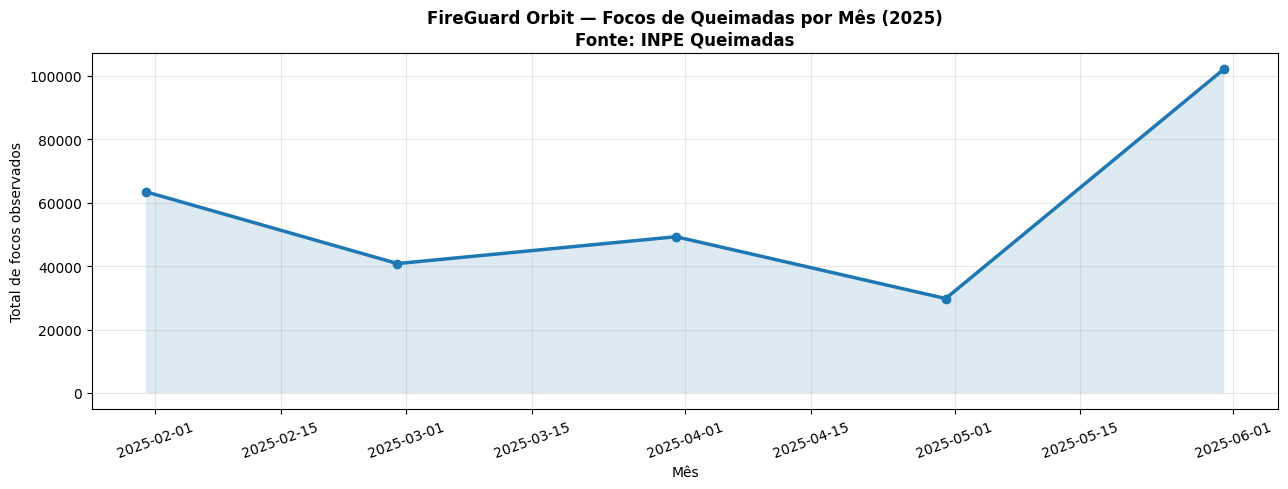

Focos por mês:
data
2025-01-31     63439
2025-02-28     40801
2025-03-31     49265
2025-04-30     29773
2025-05-31    102187


In [5]:
# ── Série temporal mensal ───────────────────────────────────────────────────
mensal = df.groupby(pd.Grouper(key='data', freq='ME'))['focos_observados'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(mensal['data'], mensal['focos_observados'], marker='o', linewidth=2.5)
ax.fill_between(mensal['data'], mensal['focos_observados'], alpha=0.15)
ax.set_title('FireGuard Orbit — Focos de Queimadas por Mês (2025)\nFonte: INPE Queimadas', fontsize=12, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Total de focos observados')
ax.grid(alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(GRAF_DIR / '01_serie_temporal_focos.png', dpi=160)
plt.show()

print('Focos por mês:')
print(mensal.set_index('data')['focos_observados'].to_string())

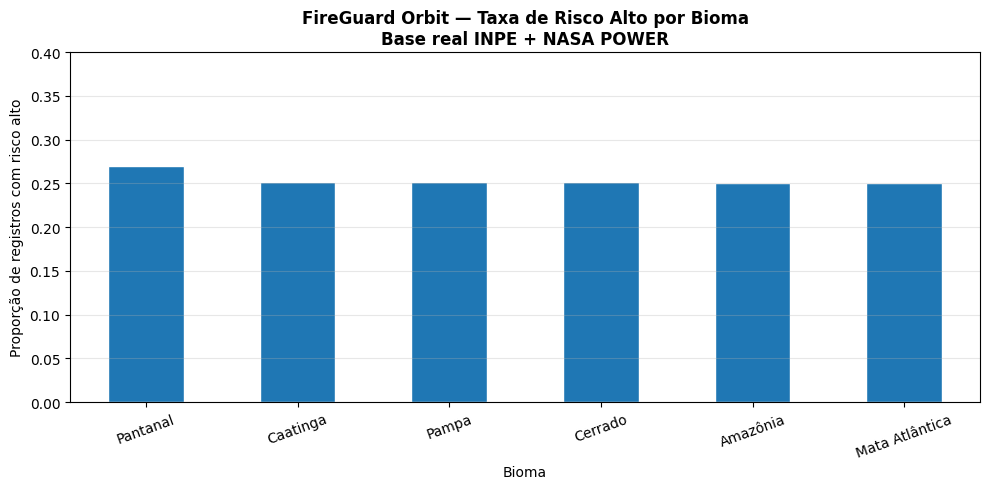

bioma
Pantanal          0.2698
Caatinga          0.2521
Pampa             0.2519
Cerrado           0.2516
Amazônia          0.2500
Mata Atlântica    0.2500
Name: risco_alto_queimada, dtype: float64


In [6]:
# ── Taxa de risco alto por bioma ────────────────────────────────────────────
risco_bioma = df.groupby('bioma')['risco_alto_queimada'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
risco_bioma.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('FireGuard Orbit — Taxa de Risco Alto por Bioma\nBase real INPE + NASA POWER', fontsize=12, fontweight='bold')
ax.set_xlabel('Bioma')
ax.set_ylabel('Proporção de registros com risco alto')
ax.set_ylim(0, max(0.4, risco_bioma.max() + 0.05))
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(GRAF_DIR / '02_risco_medio_por_bioma.png', dpi=160)
plt.show()

print(risco_bioma.round(4))

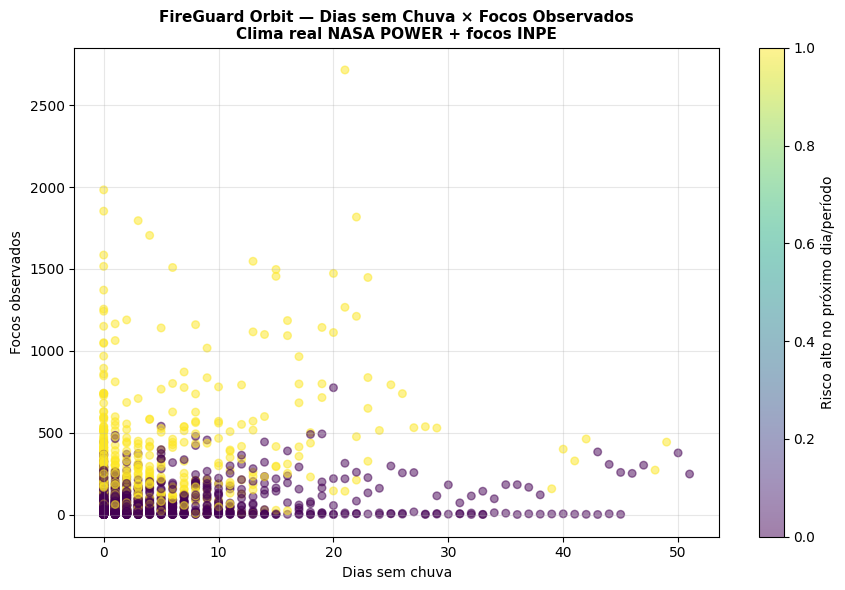

Correlação dias sem chuva × focos observados: 0.179


In [7]:
# ── Dispersão dias sem chuva × focos ─────────────────────────────────────────
amostra = df.sample(min(len(df), 2000), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    amostra['dias_sem_chuva'],
    amostra['focos_observados'],
    c=amostra['risco_alto_queimada'],
    alpha=0.5,
    s=30,
)
plt.colorbar(sc, label='Risco alto no próximo dia/período')
ax.set_title('FireGuard Orbit — Dias sem Chuva × Focos Observados\nClima real NASA POWER + focos INPE', fontsize=11, fontweight='bold')
ax.set_xlabel('Dias sem chuva')
ax.set_ylabel('Focos observados')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(GRAF_DIR / '03_dias_sem_chuva_vs_focos.png', dpi=160)
plt.show()

print(f'Correlação dias sem chuva × focos observados: {df[["dias_sem_chuva", "focos_observados"]].corr().iloc[0,1]:.3f}')

## 3.1 Agrupamentos e correlação

,temperatura_c,temperatura_max_c,umidade_pct,precipitacao_mm,dias_sem_chuva,focos_observados,risco_alto_queimada
bioma,,,,,,,
Pantanal,29.60,35.81,59.74,2.09,2.77,18.22,0.27
Amazônia,26.72,29.44,85.86,4.99,0.26,161.43,0.25
Caatinga,28.69,35.58,54.03,0.80,16.02,205.18,0.25
Cerrado,24.14,30.88,65.20,2.13,3.24,184.40,0.25
Mata Atlântica,22.16,28.71,76.24,2.43,2.14,84.06,0.25
Pampa,23.15,29.18,76.17,1.86,4.44,47.87,0.25


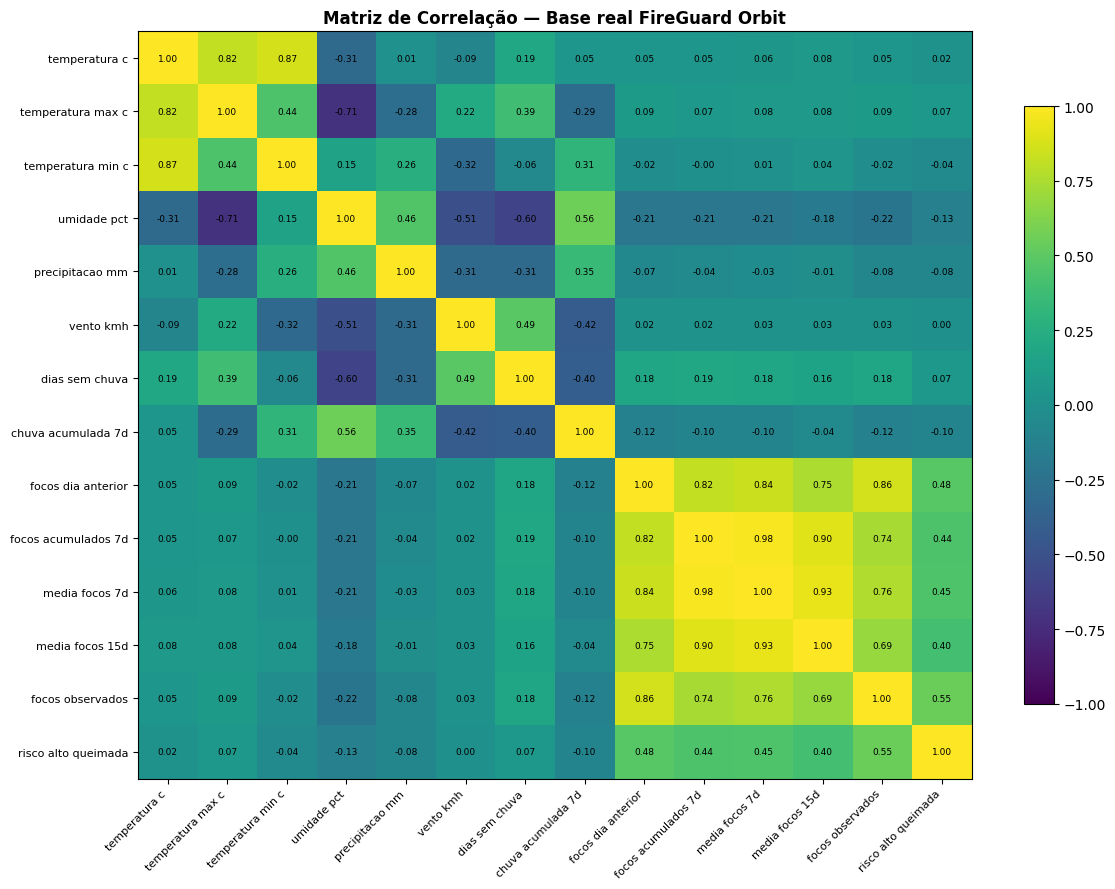

In [8]:
cols_g = [
    'temperatura_c', 'temperatura_max_c', 'umidade_pct', 'precipitacao_mm',
    'dias_sem_chuva', 'focos_observados', 'risco_alto_queimada'
]
analise = df.groupby('bioma')[cols_g].mean().round(2).sort_values('risco_alto_queimada', ascending=False)
display(analise)

cols_c = [
    'temperatura_c', 'temperatura_max_c', 'temperatura_min_c', 'umidade_pct',
    'precipitacao_mm', 'vento_kmh', 'dias_sem_chuva', 'chuva_acumulada_7d',
    'focos_dia_anterior', 'focos_acumulados_7d', 'media_focos_7d', 'media_focos_15d',
    'focos_observados', 'risco_alto_queimada'
]
corr = df[cols_c].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
labels = [c.replace('_', ' ') for c in cols_c]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=6.5)
ax.set_title('Matriz de Correlação — Base real FireGuard Orbit', fontweight='bold')
plt.tight_layout()
plt.savefig(GRAF_DIR / '05_correlacao.png', dpi=150)
plt.show()

## 4. Importância de variáveis com Random Forest

Esta etapa não define o modelo final. Ela serve como apoio interpretativo para entender quais atributos mais aparecem como relevantes em um modelo de árvore.

[OK] Pipeline Random Forest treinado
Treino: 1,574 | Teste: 525


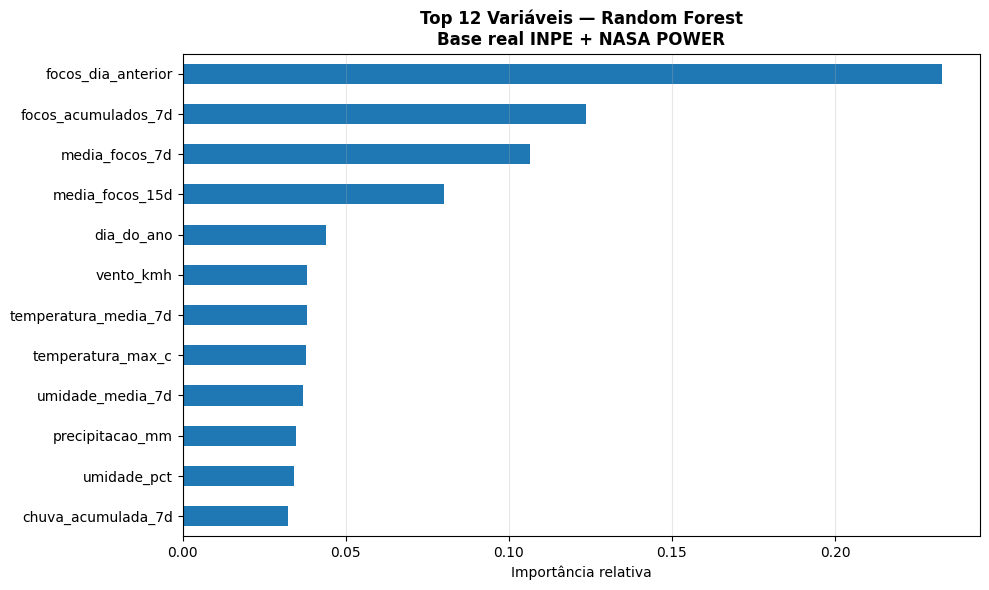

focos_dia_anterior      0.2328
focos_acumulados_7d     0.1236
media_focos_7d          0.1065
media_focos_15d         0.0801
dia_do_ano              0.0439
vento_kmh               0.0382
temperatura_media_7d    0.0381
temperatura_max_c       0.0377
umidade_media_7d        0.0368
precipitacao_mm         0.0348
umidade_pct             0.0343
chuva_acumulada_7d      0.0322
dtype: float64

In [9]:
features_categoricas = ['regiao', 'bioma']
features_numericas = [
    'mes', 'dia_do_ano',
    'temperatura_c', 'temperatura_max_c', 'temperatura_min_c',
    'umidade_pct', 'precipitacao_mm', 'vento_kmh',
    'dias_sem_chuva', 'chuva_acumulada_7d', 'umidade_media_7d', 'temperatura_media_7d',
    'focos_dia_anterior', 'focos_acumulados_7d', 'media_focos_7d', 'media_focos_15d',
]
features = features_categoricas + features_numericas
target = 'risco_alto_queimada'

X_rf = df[features]
y_rf = df[target]

pre_rf = ColumnTransformer([
    ('cat', make_ohe(), features_categoricas),
    ('num', 'passthrough', features_numericas),
])

pipe_rf = Pipeline([
    ('pre', pre_rf),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
        class_weight='balanced',
    )),
])

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_rf, y_rf, test_size=0.25, random_state=RANDOM_STATE, stratify=y_rf
)
pipe_rf.fit(Xr_tr, yr_tr)

print('[OK] Pipeline Random Forest treinado')
print(f'Treino: {len(Xr_tr):,} | Teste: {len(Xr_te):,}')

enc_out = pipe_rf.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(features_categoricas)
nomes = np.concatenate([enc_out, np.array(features_numericas)])
imp = pd.Series(pipe_rf.named_steps['model'].feature_importances_, index=nomes).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
imp.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 12 Variáveis — Random Forest\nBase real INPE + NASA POWER', fontsize=12, fontweight='bold')
ax.set_xlabel('Importância relativa')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(GRAF_DIR / '05_importancia_variaveis.png', dpi=160)
plt.show()

imp.round(4)

## 5. Benchmark de modelos

Foram testados 9 algoritmos com as mesmas features, mesma divisão treino/teste e mesmas métricas.

| Prioridade | Métrica | Justificativa |
|:---:|---|---|
| 1 | **Recall — risco alto** | Falso negativo = área crítica não detectada |
| 2 | F1-score | Desempate |
| 3 | ROC-AUC | Desempate final |

Em prevenção de queimadas, gerar um alerta extra costuma ser menos grave do que deixar de detectar uma área de risco.

In [10]:
CAT_COLS = features_categoricas
NUM_COLS = features_numericas
FEAT_BM = CAT_COLS + NUM_COLS

X_bm = df[FEAT_BM].copy()
y_bm = df[target].copy()

print('Distribuição da variável alvo:')
print(f'  Risco Normal (0): {(y_bm == 0).sum():,}  ({(y_bm == 0).mean():.1%})')
print(f'  Risco Alto   (1): {(y_bm == 1).sum():,}  ({(y_bm == 1).mean():.1%})')

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X_bm, y_bm, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bm
)
print(f'Treino: {len(Xb_tr):,} | Teste: {len(Xb_te):,}')

pre_bm = ColumnTransformer([
    ('cat', make_ohe(), CAT_COLS),
    ('num', StandardScaler(), NUM_COLS),
])

candidatos = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=100),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE, class_weight='balanced'),
}

resultados = []
obj_bm = {}

print(f"\n{'Modelo':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print('-' * 75)

for nome, modelo in candidatos.items():
    pipe = Pipeline([('pre', pre_bm), ('model', modelo)])
    pipe.fit(Xb_tr, yb_tr)
    yp = pipe.predict(Xb_te)
    ypr = pipe.predict_proba(Xb_te)[:, 1]

    r = {
        'modelo': nome,
        'accuracy': accuracy_score(yb_te, yp),
        'precision_risco_alto': precision_score(yb_te, yp, zero_division=0),
        'recall_risco_alto': recall_score(yb_te, yp, zero_division=0),
        'f1_risco_alto': f1_score(yb_te, yp, zero_division=0),
        'roc_auc': roc_auc_score(yb_te, ypr),
    }
    resultados.append(r)
    obj_bm[nome] = pipe
    print(f"{nome:<25} {r['accuracy']:>9.4f} {r['precision_risco_alto']:>10.4f} {r['recall_risco_alto']:>8.4f} {r['f1_risco_alto']:>8.4f} {r['roc_auc']:>9.4f}")

df_bm = pd.DataFrame(resultados).sort_values(
    ['recall_risco_alto', 'f1_risco_alto', 'roc_auc'], ascending=False
).reset_index(drop=True)

melhor = df_bm.iloc[0]['modelo']
print(f'\n>> Modelo selecionado: {melhor}')
print('Critério: maior recall da classe risco alto; desempate por F1 e ROC-AUC.')

df_bm.to_csv('benchmark_modelos_real.csv', index=False, encoding='utf-8')
df_bm

Distribuição da variável alvo:
  Risco Normal (0): 1,570  (74.8%)
  Risco Alto   (1): 529  (25.2%)
Treino: 1,679 | Teste: 420

Modelo                     Accuracy  Precision   Recall       F1   ROC-AUC
---------------------------------------------------------------------------
Logistic Regression          0.7452     0.4965   0.6698   0.5703    0.8261
Decision Tree                0.7619     0.5246   0.6038   0.5614    0.7095


Random Forest                0.8452     0.7662   0.5566   0.6448    0.8785


Extra Trees                  0.8476     0.7500   0.5943   0.6632    0.8925


Gradient Boosting            0.8238     0.6778   0.5755   0.6224    0.8537
AdaBoost                     0.8071     0.6404   0.5377   0.5846    0.8148


HistGradientBoosting         0.8310     0.6804   0.6226   0.6502    0.8578
KNN                          0.8310     0.7215   0.5377   0.6162    0.8451


SVM                          0.7690     0.5302   0.7453   0.6196    0.8430

>> Modelo selecionado: SVM
Critério: maior recall da classe risco alto; desempate por F1 e ROC-AUC.


,modelo,accuracy,precision_risco_alto,recall_risco_alto,f1_risco_alto,roc_auc
0,SVM,0.769048,0.530201,0.745283,0.619608,0.843048
1,Logistic Regression,0.745238,0.496503,0.669811,0.570281,0.826133
2,HistGradientBoosting,0.830952,0.680412,0.622642,0.650246,0.857830
3,Decision Tree,0.761905,0.524590,0.603774,0.561404,0.709530
4,Extra Trees,0.847619,0.750000,0.594340,0.663158,0.892501
5,Gradient Boosting,0.823810,0.677778,0.575472,0.622449,0.853653
6,Random Forest,0.845238,0.766234,0.556604,0.644809,0.878515
7,KNN,0.830952,0.721519,0.537736,0.616216,0.845106
8,AdaBoost,0.807143,0.640449,0.537736,0.584615,0.814776


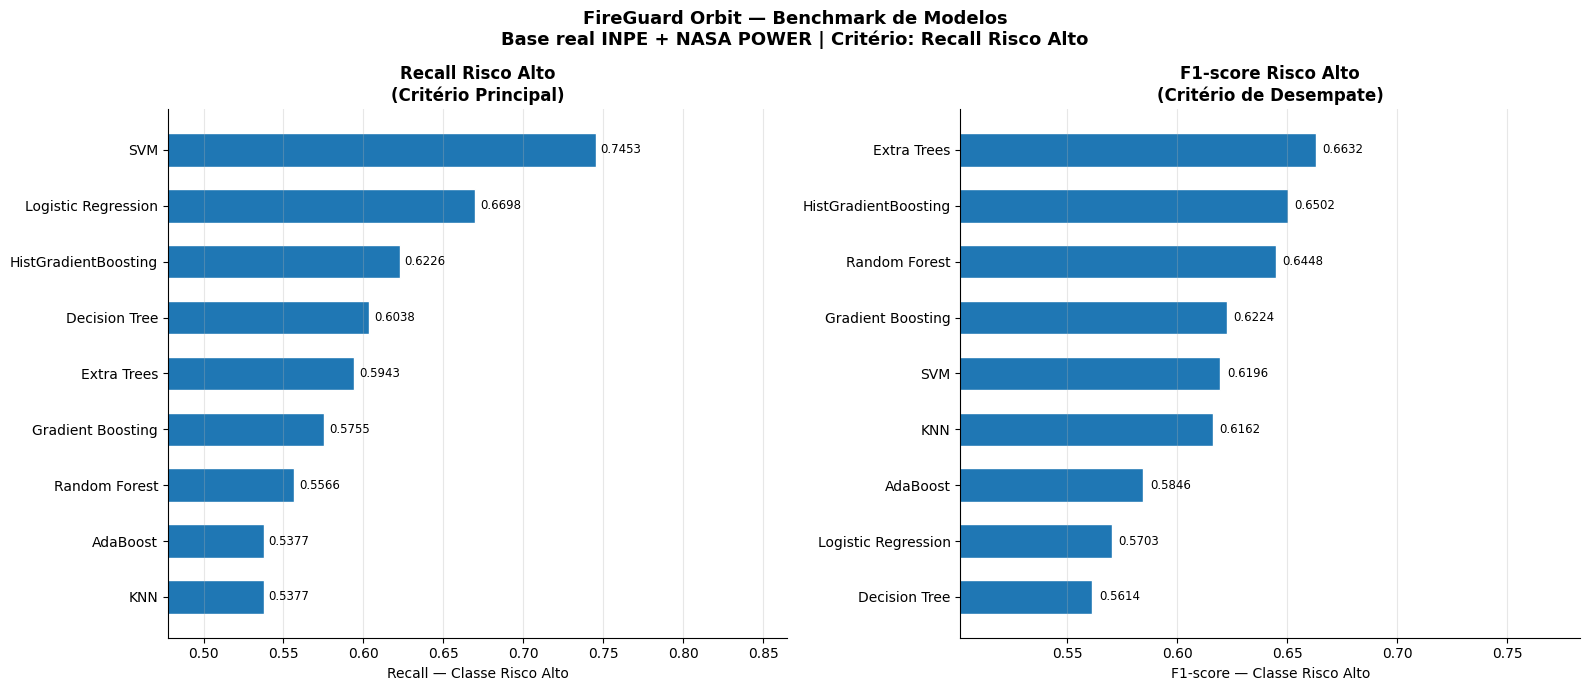

In [11]:
# ── Gráfico comparativo ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('FireGuard Orbit — Benchmark de Modelos\nBase real INPE + NASA POWER | Critério: Recall Risco Alto', fontsize=13, fontweight='bold')

dr = df_bm.sort_values('recall_risco_alto', ascending=True)
b1 = axes[0].barh(dr['modelo'], dr['recall_risco_alto'], edgecolor='white', height=0.6)
axes[0].set_xlabel('Recall — Classe Risco Alto')
axes[0].set_title('Recall Risco Alto\n(Critério Principal)', fontweight='bold')
axes[0].set_xlim(max(0, dr['recall_risco_alto'].min() - 0.06), min(1.01, dr['recall_risco_alto'].max() + 0.12))
for bar, v in zip(b1, dr['recall_risco_alto']):
    axes[0].text(v + 0.003, bar.get_y() + bar.get_height() / 2, f'{v:.4f}', va='center', ha='left', fontsize=8.5)
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

df1 = df_bm.sort_values('f1_risco_alto', ascending=True)
b2 = axes[1].barh(df1['modelo'], df1['f1_risco_alto'], edgecolor='white', height=0.6)
axes[1].set_xlabel('F1-score — Classe Risco Alto')
axes[1].set_title('F1-score Risco Alto\n(Critério de Desempate)', fontweight='bold')
axes[1].set_xlim(max(0, df1['f1_risco_alto'].min() - 0.06), min(1.01, df1['f1_risco_alto'].max() + 0.12))
for bar, v in zip(b2, df1['f1_risco_alto']):
    axes[1].text(v + 0.003, bar.get_y() + bar.get_height() / 2, f'{v:.4f}', va='center', ha='left', fontsize=8.5)
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(GRAF_DIR / '06_benchmark_modelos.png', dpi=160, bbox_inches='tight')
plt.show()

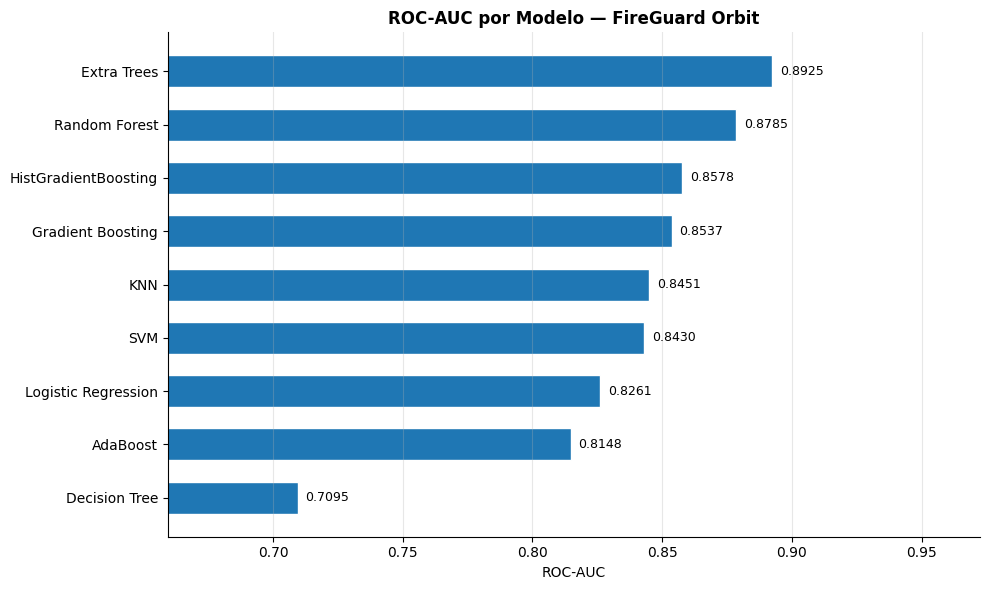

In [12]:
# ── ROC-AUC comparativo ─────────────────────────────────────────────────────
df_auc = df_bm.sort_values('roc_auc', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_auc['modelo'], df_auc['roc_auc'], edgecolor='white', height=0.6)
ax.set_xlabel('ROC-AUC')
ax.set_title('ROC-AUC por Modelo — FireGuard Orbit', fontweight='bold')
ax.set_xlim(max(0, df_auc['roc_auc'].min() - 0.05), min(1.01, df_auc['roc_auc'].max() + 0.08))
for bar, v in zip(bars, df_auc['roc_auc']):
    ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2, f'{v:.4f}', va='center', ha='left', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(GRAF_DIR / '07_roc_auc_comparativo.png', dpi=160)
plt.show()

## 5.1 Por que o modelo final foi escolhido?

O modelo final foi escolhido pelo **recall da classe risco alto**, pois o objetivo da solução é apoiar prevenção. Nesse contexto, o erro mais crítico é o falso negativo: uma área ou período crítico que não recebe alerta.

As métricas ficaram mais realistas do que na versão com variáveis simuladas, mas a conclusão é mais defensável porque a base final usa focos reais do INPE e clima real da NASA POWER.

## 6. Avaliação do modelo final

In [13]:
pipe_final = obj_bm[melhor]
yp_f = pipe_final.predict(Xb_te)
ypr_f = pipe_final.predict_proba(Xb_te)[:, 1]

metricas_final = {
    'modelo_escolhido': melhor,
    'criterio_de_escolha': 'Maior recall da classe risco_alto_queimada; desempate por F1 e ROC-AUC.',
    'base_utilizada': 'data/dados_fireguard_orbit_real.csv',
    'features_categoricas': CAT_COLS,
    'features_numericas': NUM_COLS,
    'metricas': df_bm.iloc[0].to_dict(),
    'matriz_confusao': confusion_matrix(yb_te, yp_f).tolist(),
    'classification_report': classification_report(yb_te, yp_f, output_dict=True),
    'roc_auc_calculado_no_teste': roc_auc_score(yb_te, ypr_f),
}

print('=== MÉTRICAS DO MODELO FINAL ===')
for k, v in metricas_final['metricas'].items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

print('\n=== RELATÓRIO DE CLASSIFICAÇÃO ===')
print(classification_report(yb_te, yp_f, target_names=['Normal', 'Risco Alto']))

with open('resultados_modelo_real.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_final, f, ensure_ascii=False, indent=2)

=== MÉTRICAS DO MODELO FINAL ===
  modelo: SVM
  accuracy: 0.7690
  precision_risco_alto: 0.5302
  recall_risco_alto: 0.7453
  f1_risco_alto: 0.6196
  roc_auc: 0.8430

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

      Normal       0.90      0.78      0.83       314
  Risco Alto       0.53      0.75      0.62       106

    accuracy                           0.77       420
   macro avg       0.72      0.76      0.73       420
weighted avg       0.81      0.77      0.78       420



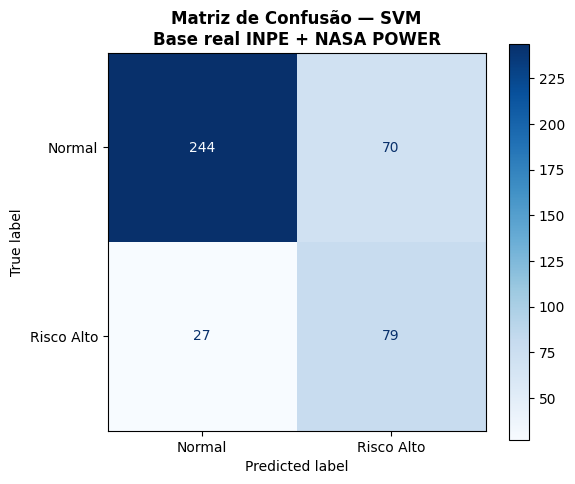

Verdadeiros Negativos (normal correto)           : 244
Falsos Positivos      (alerta extra)             : 70
Falsos Negativos      (área crítica não detect.) : 27  <- minimizar
Verdadeiros Positivos (risco alto correto)        : 79


In [14]:
# ── Matriz de confusão ───────────────────────────────────────────────────────
cm = confusion_matrix(yb_te, yp_f)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Risco Alto'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format='d', colorbar=True, cmap='Blues')
ax.set_title(f'Matriz de Confusão — {melhor}\nBase real INPE + NASA POWER', fontweight='bold')
plt.tight_layout()
plt.savefig(GRAF_DIR / '04_matriz_confusao.png', dpi=160)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros Negativos (normal correto)           : {tn:,}')
print(f'Falsos Positivos      (alerta extra)             : {fp:,}')
print(f'Falsos Negativos      (área crítica não detect.) : {fn:,}  <- minimizar')
print(f'Verdadeiros Positivos (risco alto correto)        : {tp:,}')

## 7. Conclusão

O FireGuard Orbit usa **focos reais de queimadas do INPE**, **dados meteorológicos reais da NASA POWER** e **variáveis históricas derivadas** para prever risco alto de queimadas.

**Resultados principais:**

- 9 algoritmos testados com o mesmo protocolo;
- modelo escolhido pelo recall da classe risco alto;
- métricas mais realistas e mais defensáveis do que a versão com variáveis simuladas;
- base final reproduzível por scripts.

**Frase para defesa oral:**

> “Na versão final, substituímos as variáveis ambientais simuladas por dados meteorológicos reais da NASA POWER. O modelo usa focos reais do INPE, clima real e variáveis históricas para prever risco alto de queimadas. Testamos 9 algoritmos e escolhemos o modelo pelo recall da classe risco alto, porque o erro mais grave é deixar de sinalizar uma área crítica.”